---
title: Spark RDD with distributed machine learning
image: ./images/rdd.png 
description: Understanding Spark computational model with logistic regression and clustering
ord: 4
format:
    html:
        code-block-background: true
        code-fold: false
        toc: true
---

In this blog post I take a close look into the Spark computational model by implementing 2 machine learning algorithms: Logistic Regression and K-Means clustering.

The code is executed in the Databricks environment using Scala. Python is used for visualization.

Databricks [notebook](https://databricks-prod-cloudfront.cloud.databricks.com/public/4027ec902e239c93eaaa8714f173bcfc/3756302453323559/2672913114616530/2768646450526944/latest.html)       [<img src="./images/databricks.jpeg" alt="drawing" width="100"/>](https://databricks-prod-cloudfront.cloud.databricks.com/public/4027ec902e239c93eaaa8714f173bcfc/3756302453323559/2672913114616530/2768646450526944/latest.html)

________________________________________

Spark was developed to address iterative big data algorithms like logistic regression (gradient descent) or k-means clustering. From the RDDs [paper](https://www.usenix.org/system/files/conference/nsdi12/nsdi12-final138.pdf):

![](./images/sparkmotivation.png)

# K-Means clustering

## Data
For K-means clustering let's generate 5 clusters of data.

[array([ 8.57032532, -3.64137432]), array([-6.34270089, -5.91962725]), array([1.3294662 , 1.87901003]), array([9.31274039, 3.05338878]), array([4.96798439, 3.09705577])]


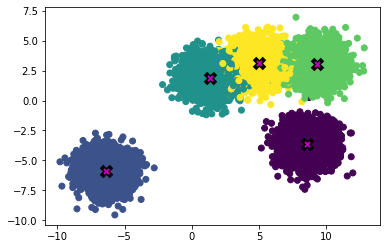

In [ ]:
#| code-fold: true
#| code-summary: "Generate data (Python)"

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import csv

n_samples = 10000
n_features = 2
n_clusters = 5

data, labels = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, random_state=12345)


def plot_centroids(centroids,ax):
    for i, centroid in enumerate(centroids):
        samples = data[i*n_samples:(i+1)*n_samples]
        ax.plot(*centroid, markersize=10, marker="x", color='k', mew=5)
        ax.plot(*centroid, markersize=5, marker="x", color='m', mew=2)

_,ax = plt.subplots()
ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis')

centroids = []
for cluster_label in range(n_clusters):
    cluster_points = data[labels == cluster_label]  # Select data points in the current cluster
    cluster_centroid = np.mean(cluster_points, axis=0)  # Calculate the centroid for the cluster
    centroids.append(cluster_centroid)

plot_centroids(centroids,ax)
print(centroids)


#save data
with open('data.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(data)

Let's read the data and create an RDD of data points, 

Also important to make sure that RDD of data points will be cached, so we don't need to recompute it for each iteration. 

```scala
import scala.io.Source

def getPointsRDD(): RDD[(Float,Float)] = {
    val source = Source.fromFile("data.csv")
    val linesRDD = sc.parallelize(source.getLines().toList)
    return linesRDD.map(_.split(',').map(_.toFloat)).map({case Array(x,y) => (x,y)})
}
val points = getPointsRDD().cache()
```

We can see that data points were split by Spark in 8 partitions:

```scala
points.getNumPartitions
```
```
res5: Int = 8
```

## Initialize centroids
The first step of k-means clustering is to initialize the first estimates of the centroids. For this example I randomly sample 5 points, but in real applications this initialization step usually involves more sophisticated sampling.  

```scala
val randomMeans = points.takeSample(withReplacement=false, num=5, seed=10)
```


<details closed>
  <summary>save centroids for plotting</summary>

```scala
import java.io.PrintWriter

def saveResult(means: Array[(Float,Float)]) = {
    val writer = new PrintWriter("means.txt")
    try {
        means.foreach(writer.println)
    } finally {
        writer.close()
    }
}

saveResult(randomMeans)
```
</details>

Out[5]: Text(0.5, 1.0, 'Initial centroids against true centrids')

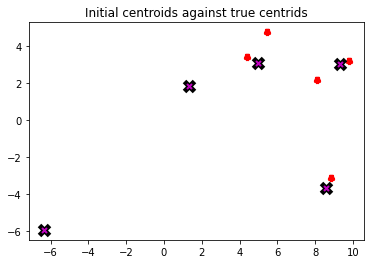

In [ ]:
#| code-fold: true
#| code-summary: "Plot centroids (Python)"

# Open the file in read mode
def readResults()->list:
    with open('means.txt', 'r') as file:
        lines = file.readlines()
    return [tuple(map(float, line.strip('()\n').split(','))) for line in lines]

def plot_results(centroids,ax):
    for i, centroid in enumerate(centroids):
        samples = data[i*n_samples:(i+1)*n_samples]
        ax.plot(*centroid, markersize=5, marker="*", color='r', mew=5)

first_state = readResults()
_,ax = plt.subplots()
plot_results(first_state,ax)
plot_centroids(centroids,ax)
ax.set_title('Initial centroids against true centroids')


## Define computational graph

Let's implement k-means clustering.

The main function `update` - conceptually performs 2 steps:

1) Groups the points by the closest centroids 
2) Finds the centre of the groups, effectively obtaining the new estimate for centroids

```scala
def euclideanDistance(v1: (Float, Float), v2: (Float, Float)): Double =
    (v1._1 - v2._1) * (v1._1 - v2._1) + (v1._2 - v2._2) * (v1._2 - v2._2)

  /** Return the center that is the closest to `p` */
def findClosest(p: (Float, Float), centers: Array[(Float, Float)]): (Float, Float) =
    centers.minBy(euclideanDistance(_,p))

def updateMeans(means: Array[(Float,Float)], points: RDD[(Float,Float)]): Array[(Float,Float)] =
  return points
            .map(point => (findClosest(point,means),point)) // pair (closest mean, point)
            .mapValues(point => (point,1))  // add counter for aggregation
            .reduceByKey({case ((p1,cnt1),(p2,cnt2)) => ((p1._1 + p2._1,p1._2+p2._2),cnt1+cnt2)}) // sum all the points around a centroid 
            .mapValues({case (sum,count) => (sum._1/count, sum._2/count)}) // average aggregated points -> new centroid 
            .map({case (oldMean, newMean) => newMean})
            .collect()
```

## Running the algorithm
Let's run 10 iterations and look at the result.

```scala
var means = randomMeans
for(i <- 0 to 10){
  means = updateMeans(means,points) 
}
```

<details closed>
  <summary>save results for plotting</summary>

```scala
saveResult(means)
```

</details>

The algorithm successfully found true centroids of clusters.

Out[5]: Text(0.5, 1.0, 'True centroids')

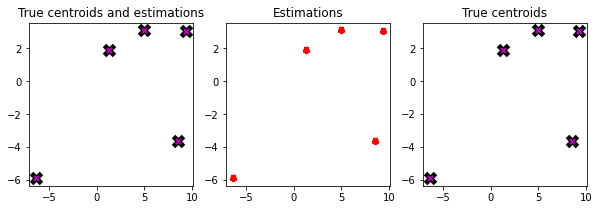

In [ ]:
#| code-fold: true
#| code-summary: "Plot results (Python)"

results = readResults()
_,ax = plt.subplots(1,3,figsize=(10,3))
plot_results(results,ax[0])
plot_centroids(centroids,ax[0])
plot_results(results,ax[1])
plot_centroids(centroids,ax[2])
ax[0].set_title('True centroids and estimations')
ax[1].set_title('Estimations')
ax[2].set_title('True centroids')

## Execution analysis

First, Spark builds a graph of computations and only when we call `action` functions such as .collect() it executes the graph. 

Let's look at the diagram of the execution process. 

![](./images/kmns.png)

Spark driver creates closures with centroids and sends them to the executors.
Executors apply closures received by the driver to the partitions. 

From the spark [paper](https://www.usenix.org/system/files/conference/nsdi12/nsdi12-final138.pdf): *"..users provide arguments to RDD operations like map by passing closures (function literals).
Scala represents each closure as a Java object, and
these objects can be serialized and loaded on another
node to pass the closure across the network. Scala also
saves any variables bound in the closure as fields in
the Java object."*

First each partition of points is transformed to the pairs of points and the corresponding closest centroid. 

Then we have reduceByKey followed by shuffle and the average. It is conceptually the same as grouping the points by key and taking the average, but computationally more optimal. If we used groupByKey, then the shuffle operation would have to send 10000 points over the network in the worst case. With reduceByKey operation, reduction happens before shuffle occurs, significantly reducing the amount of data to send. In this case for each cluster data points are reduced to a single pair of sum and counts, which means that at most 5 (number of clusters) * 8 (number of partitions) = 40 pairs would need to be sent over the network.     

The obtained centroids are then sent back to the driver. 

Next iteration driver sends updated centroids back to the executors for recomputation. 


# Logistic regression

## Data
Let's generate data for binary classification problem

Out[15]: Text(0, 0.5, 'Feature 2')

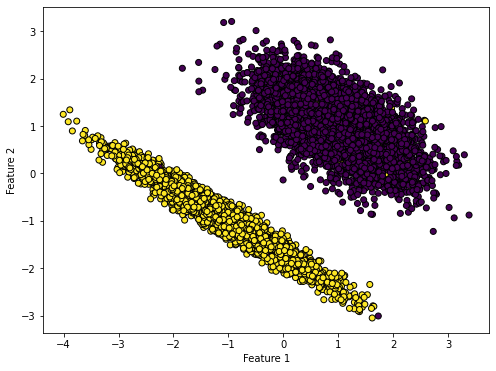

In [ ]:
#| code-fold: true
#| code-summary: "generate data (Python)"

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


X, y = make_classification(n_samples=10000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=123)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [ ]:
#| code-fold: true
#| code-summary: "save data (Python)"

import numpy as np
data = np.column_stack((X.astype(str), y.astype(str)))
np.savetxt('classification_data.txt', data, fmt='%s')


<details closed>
  <summary>reading data</summary>

  ```scala
import scala.io.Source

case class Point(coordinates:List[Double], label:Int)

def readData(): List[Point] = {
    val filePath = "classification_data.txt"
    val lines = Source.fromFile(filePath).getLines().toList
    val points: List[Point] = lines.map { line =>
        val fields = line.split("\\s+")
        val x = fields.init.map(_.toDouble).toList
        val y = fields.last.toInt
        Point(x, y)
    }
    return points
}

val points = readData()
  ```
</details>

## Model
For a 2 dimensional problem binary classification model would look like this:

$p = \sigma(\beta_0 + \beta_1*x_1 + \beta_2*x_2)$ 

where p is the probability of a data point to belong to class 1, $\beta_i$ - learnable model parameters

We can implement it in Scala in the following way:


```scala

import math.exp

def linear(x: List[Double], beta: List[Double]): Double =
    return (1.0 :: x).zip(beta).map({case (a, b) => a * b}).reduce(_ + _) // dot product x*beta, append 1 for beta_0

def sigmoid(x: Double): Double =
    1 / (1 + math.exp(-x).toFloat)

def model(x: List[Double], beta: List[Double]): Double =
    sigmoid(linear(x, beta))

```


## Cost function and gradient

We need to minimize the cost function $J$:

$J = - \frac{1}{N} * \sum_{k=0}^{N}[y_k*log(p_k) + (1-y_k)*log(1-p_k)]$

where $N$ - total number of points

And the corresponding partial derivative with respect to each parameter is:

$\frac{dJ}{d{\beta}_i} = \frac{1}{N} * \sum_{k=0}^{N} x_i*(p_k - y_k)$

For gradient descent we need to compute gradient at each iteration and update parameters.

Implementation of the gradient $[\frac{dJ}{d{{\beta}}_0}, \frac{dJ}{d{{\beta}}_1}, \frac{dJ}{d{\beta}_2}]$ computation and loss function:

```scala

def partial_derivative(y:Int,pred:Double,x:Double): Double = (pred-y)*x    

def gradient(xs:List[Double], pred:Double, y:Int): List[Double] = {
    (1.0::xs).map(x => partial_derivative(y,pred,x)) // add 1 to xs to acount for b0
}

def loss(pred:Double,y:Int): Double = {
    -(y*log(pred) + (1-y)*log(1-pred))
}
```

## Define computational graph

Let's define our computation graph for one iteration of logistic regression. We want to compute gradients for all data points and find their average. For monitoring also let's compute loss for each iteration as well.

```scala
import math.log

/* Sum gradients and loss values */
def sum(a:(List[Double],Double,Int), b:(List[Double],Double,Int)): (List[Double],Double,Int) = {
    val (grad1,loss1,cnt1) = a
    val (grad2,loss2,cnt2) = b
    val grad_sum = grad1.zip(grad2).map({case (g1,g2) => g1+g2})
    val loss_sum = loss1+loss2
    val count = cnt1 + cnt2
    (grad_sum,loss_sum,count)
}

/*Compute average for gradients and the loss value*/
def average(grad_sum:List[Double], loss_sum:Double,counts:Int): (List[Double],Double) = {
    (grad_sum.map(_/counts),loss_sum/counts)
}

/*Compute gradient and loss value*/
def compute(points:RDD[Point],params:List[Double]): (List[Double],Double,Int) = 
    points.map({case Point(xs,y) => (Point(xs,y), model(xs,params))}) // get predictions
    .map({case (Point(xs,y),pred) => (gradient(xs,pred,y),loss(pred,y),1)}) // compute gradient and loss
    .reduce(sum)
```

## Running the training

Running the training. 10 iterations. Compute average gradient and loss for each iteration and perform gradient descent step

$parameters_n = parameters_{n-1} - \alpha * \nabla J$

```scala
val pointsRDD = sc.parallelize(points)

var parameters = List(0.1,0.1,0.1) // b0,b1,b2 random

val step_size = 3
for(i <- 0 to 10){
    val (gradSum,lossSum,cnt) = compute(pointsRDD,parameters)
    val (grad,loss) = average(gradSum,lossSum,cnt)
    parameters = parameters.zip(grad).map({case (param,g) => param - step_size*g})
    println(loss)
}
```

<details closed>
  <summary>loss output</summary>
```
0.7985616355198335
0.07500786607886242
0.06578866845350452
0.05999996600024983
0.05603349371988779
0.05315514097244599
0.05097938292867146
0.04928355967304257
0.04792987072323888
0.046828371238424885
0.04591785644633872
```
</details>


Computing accuracy:

```scala
val accuracy = pointsRDD.map(point => (point.label,model(point.coordinates,parameters)))
.map({case (y,prediction) => if( (prediction > 0.5) == (y==1) ) 1 else 0})
.mean
```

```
accuracy = 0.9945
```

Let's plot the decision boundary for the obtained model:


<details closed>
  <summary>save results</summary>
  
  ```scala
  import java.io.PrintWriter

  def saveParameters(parameters: List[Double]) = {
      new PrintWriter("parameters.txt") {
      // Iterate through the array and write each element to the file
      parameters.foreach(println)
      close()
    }
  }

  saveParameters(parameters)
  ```
</details>

Out[17]: [<matplotlib.lines.Line2D at 0x7eff0c05adf0>]

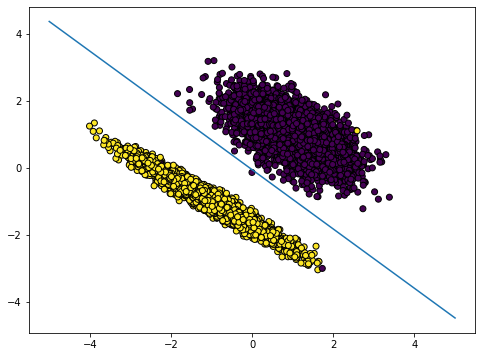

In [ ]:
#| code-fold: true
#| code-summary: "plot results (Python)"

with open('parameters.txt', 'r') as file:
    parameters = [float(line.strip()) for line in file]

def get_decision_line(b0,b1,b2):
    c = -b0/b2
    m = -b1/b2
    return lambda x: m*x + c

xs = np.linspace(-5,5)
ys = get_decision_line(*parameters)(xs)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolors='k')
plt.plot(xs, ys)


## Execution analysis

Logistic regression iteration doesn't require shuffle operation. We simply apply the sequence of `map` operations to compute gradients and losses for each point and then do `reduce` to aggregate.
The final step of the iteration happens on the driver. The Driver receives aggregated gradients and losses from the executors, computes the average and performs gradient descent update step. The updated parameters are then sent to the executors for the next iteration. 

![](./images/logreg.png)